# Résumés de Textes Abstraits avec le Modèle Transformer-BART
### Projet de Fin de Formation — Bootcamp Data Scientist | GoMyCode
**Étudiant :** Cheikh Ahmed Tidiane DIOP  
**Modèle utilisé :** facebook/bart-large-cnn (HuggingFace)  
**Dataset :** CNN / DailyMail  
**Date :** Mai 2026

---

## Objectifs du Projet
1. Préparer et prétraiter des données textuelles (CNN/DailyMail)
2. Charger et fine-tuner le modèle pré-entraîné BART
3. Évaluer les performances avec le score ROUGE
4. Déployer une interface interactive avec Gradio
5. Présenter les résultats de manière professionnelle

---
##  Plan du Notebook
- **Phase 1** : Installation & Configuration
- **Phase 2** : Data Preparation & Preprocessing
- **Phase 3** : Fine-tuning du modèle BART
- **Phase 4** : Évaluation avec ROUGE
- **Phase 5** : Implémentation & Interface Gradio
- **Phase 6** : Présentation des Résultats

---
#  PHASE 1 — Installation & Configuration

In [45]:
# ============================================================
#  INSTALLATION DE TOUTES LES BIBLIOTHÈQUES NÉCESSAIRES
# ============================================================
# Ne modifie rien ici, exécute simplement cette cellule

!pip install transformers datasets rouge-score gradio sentencepiece accelerate -q

print(" Toutes les bibliothèques sont installées avec succès !")

 Toutes les bibliothèques sont installées avec succès !


In [46]:
# ============================================================
#  VÉRIFICATION DU GPU
# ============================================================
import torch

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    print(f" GPU détecté : {gpu_name}")
    print(f"   Mémoire disponible : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print(" Aucun GPU détecté. Va dans Exécution > Modifier le type d'exécution > GPU T4")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n Appareil utilisé : {device}")

 GPU détecté : Tesla T4
   Mémoire disponible : 15.6 GB

 Appareil utilisé : cuda


In [47]:
# ============================================================
#  IMPORTATION DES BIBLIOTHÈQUES
# ============================================================

# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# HuggingFace — pour le modèle BART
from transformers import (
    BartForConditionalGeneration,
    BartTokenizer,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq
)
from datasets import load_dataset

# Évaluation
from rouge_score import rouge_scorer

# Interface
import gradio as gr

# Affichage
from IPython.display import display, HTML

print(" Bibliothèques de base importées")
print(" HuggingFace Transformers importé")
print(" Datasets importé")
print(" ROUGE Score importé")
print(" Gradio importé")
print("\n Tout est prêt ! On peut commencer !")

 Bibliothèques de base importées
 HuggingFace Transformers importé
 Datasets importé
 ROUGE Score importé
 Gradio importé

 Tout est prêt ! On peut commencer !


---
# PHASE 2 — Data Preparation & Preprocessing

##  Qu'est-ce que CNN/DailyMail ?
C'est un dataset standard de référence pour la summarisation de texte.  
Il contient des **articles de presse** et leurs **résumés** (highlights).  
- **Articles** : textes longs (~800 mots)
- **Résumés** : 3-5 points clés (~55 mots)

In [48]:
# ============================================================
#  CHARGEMENT DU DATASET CNN/DAILYMAIL
# ============================================================

print(" Chargement du dataset CNN/DailyMail en cours...")
print("   (Cela peut prendre 3-5 minutes, sois patient)")

# Chargement de la version 3.0.0 du dataset
dataset = load_dataset("cnn_dailymail", "3.0.0")

print("\n Dataset chargé avec succès !")
print(f"\n📊 Structure du dataset :")
print(f"   🔵 Entraînement (train)      : {len(dataset['train']):,} articles")
print(f"   🟡 Validation (validation)   : {len(dataset['validation']):,} articles")
print(f"   🟢 Test (test)               : {len(dataset['test']):,} articles")

 Chargement du dataset CNN/DailyMail en cours...
   (Cela peut prendre 3-5 minutes, sois patient)

 Dataset chargé avec succès !

📊 Structure du dataset :
   🔵 Entraînement (train)      : 287,113 articles
   🟡 Validation (validation)   : 13,368 articles
   🟢 Test (test)               : 11,490 articles


In [49]:
# ============================================================
#  EXPLORATION DES DONNÉES
# ============================================================

# Affichage d'un exemple
example = dataset['train'][0]

print("=" * 70)
print(" EXEMPLE D'UN ARTICLE DU DATASET")
print("=" * 70)

print("\n ARTICLE (texte original) :")
print("-" * 50)
print(example['article'][:500] + "...\n")  # On affiche les 500 premiers caractères

print("\n RÉSUMÉ (highlights) :")
print("-" * 50)
print(example['highlights'])

print("\n" + "=" * 70)
print(f"📏 Longueur de l'article   : {len(example['article'].split())} mots")
print(f"📏 Longueur du résumé      : {len(example['highlights'].split())} mots")
print(f"📉 Taux de compression     : {len(example['highlights'].split()) / len(example['article'].split()) * 100:.1f}%")

 EXEMPLE D'UN ARTICLE DU DATASET

 ARTICLE (texte original) :
--------------------------------------------------
LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don't plan to be one of those people who, as s...


 RÉSUMÉ (highlights) :
--------------------------------------------------
Harry Potter star Daniel Radcliffe gets £20M fortune as he turns 18 Monday .
Young actor says he has no plans to fritter his cash away .
Radcliffe's earnings from first five Potter films have been held in trust fund .

📏 Longueur de l'article   : 455 mots
📏 Longueur du résumé      : 41 mots
📉 Taux de compr

 STATISTIQUES DES DONNÉES (sur 1000 exemples)

 ARTICLES :
   Longueur moyenne  : 592 mots
   Longueur médiane  : 547 mots
   Longueur min      : 50 mots
   Longueur max      : 1743 mots

 RÉSUMÉS :
   Longueur moyenne  : 43 mots
   Longueur médiane  : 43 mots
   Longueur min      : 23 mots
   Longueur max      : 66 mots


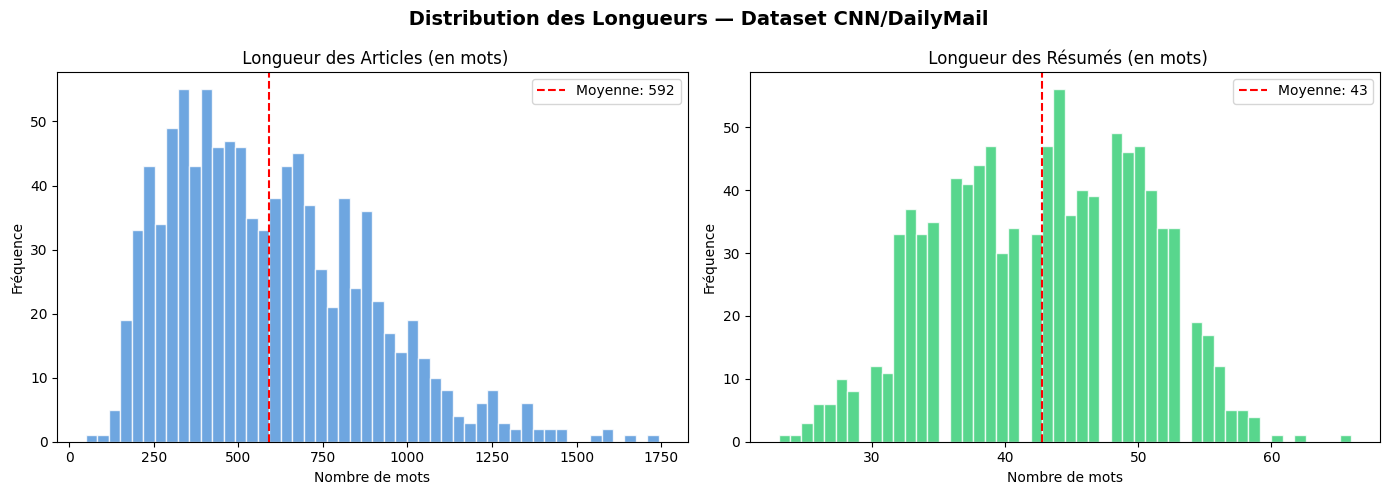


 Graphique sauvegardé : distribution_longueurs.png


In [50]:
# ============================================================
#  ANALYSE STATISTIQUE DES DONNÉES
# ============================================================

# On prend 1000 exemples pour l'analyse (plus rapide)
sample_size = 1000
sample = dataset['train'].select(range(sample_size))

# Calcul des longueurs
article_lengths = [len(ex['article'].split()) for ex in sample]
summary_lengths = [len(ex['highlights'].split()) for ex in sample]

# Statistiques
print(" STATISTIQUES DES DONNÉES (sur 1000 exemples)")
print("=" * 50)
print(f"\n ARTICLES :")
print(f"   Longueur moyenne  : {np.mean(article_lengths):.0f} mots")
print(f"   Longueur médiane  : {np.median(article_lengths):.0f} mots")
print(f"   Longueur min      : {min(article_lengths)} mots")
print(f"   Longueur max      : {max(article_lengths)} mots")

print(f"\n RÉSUMÉS :")
print(f"   Longueur moyenne  : {np.mean(summary_lengths):.0f} mots")
print(f"   Longueur médiane  : {np.median(summary_lengths):.0f} mots")
print(f"   Longueur min      : {min(summary_lengths)} mots")
print(f"   Longueur max      : {max(summary_lengths)} mots")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(' Distribution des Longueurs — Dataset CNN/DailyMail',
             fontsize=14, fontweight='bold')

# Graphique 1 : Articles
axes[0].hist(article_lengths, bins=50, color='#4A90D9', edgecolor='white', alpha=0.8)
axes[0].set_title(' Longueur des Articles (en mots)', fontsize=12)
axes[0].set_xlabel('Nombre de mots')
axes[0].set_ylabel('Fréquence')
axes[0].axvline(np.mean(article_lengths), color='red', linestyle='--',
               label=f'Moyenne: {np.mean(article_lengths):.0f}')
axes[0].legend()

# Graphique 2 : Résumés
axes[1].hist(summary_lengths, bins=50, color='#2ECC71', edgecolor='white', alpha=0.8)
axes[1].set_title(' Longueur des Résumés (en mots)', fontsize=12)
axes[1].set_xlabel('Nombre de mots')
axes[1].set_ylabel('Fréquence')
axes[1].axvline(np.mean(summary_lengths), color='red', linestyle='--',
               label=f'Moyenne: {np.mean(summary_lengths):.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('distribution_longueurs.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Graphique sauvegardé : distribution_longueurs.png")

In [51]:
# ============================================================
# 🔧 CHARGEMENT DU TOKENIZER BART
# ============================================================

MODEL_NAME = "facebook/bart-large-cnn"

print(f" Chargement du tokenizer : {MODEL_NAME}")
tokenizer = BartTokenizer.from_pretrained(MODEL_NAME)
print(f" Tokenizer chargé !")
print(f"   Taille du vocabulaire : {tokenizer.vocab_size:,} tokens")

# Paramètres de tokenisation
MAX_INPUT_LENGTH = 1024
MAX_TARGET_LENGTH = 128

print(f"\n Paramètres de tokenisation :")
print(f"   Longueur max article : {MAX_INPUT_LENGTH} tokens")
print(f"   Longueur max résumé  : {MAX_TARGET_LENGTH} tokens")


# ============================================================
# 🔧 FONCTION DE PRÉTRAITEMENT CORRIGÉE
# ============================================================

def preprocess_function(examples):
    """
    Version corrigée — compatible avec HuggingFace récent.
    Sans as_target_tokenizer (déprécié).
    """
    # Tokenisation des articles (inputs)
    model_inputs = tokenizer(
        examples['article'],
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding='max_length'
    )

    # Tokenisation des résumés (labels) — VERSION CORRIGÉE
    labels = tokenizer(
        text_target=examples['highlights'],
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
        padding='max_length'
    )

    model_inputs['labels'] = labels['input_ids']
    return model_inputs

print("\n Fonction de prétraitement corrigée et prête !")

 Chargement du tokenizer : facebook/bart-large-cnn
 Tokenizer chargé !
   Taille du vocabulaire : 50,265 tokens

 Paramètres de tokenisation :
   Longueur max article : 1024 tokens
   Longueur max résumé  : 128 tokens

 Fonction de prétraitement corrigée et prête !


In [52]:
# ============================================================
#  SÉLECTION D'UN SOUS-ENSEMBLE ET TOKENISATION
# ============================================================

# Tailles des sous-ensembles
TRAIN_SIZE = 2000
VAL_SIZE   = 200
TEST_SIZE  = 200

print(f" Sélection des sous-ensembles :")
print(f"   Train      : {TRAIN_SIZE} exemples")
print(f"   Validation : {VAL_SIZE} exemples")
print(f"   Test       : {TEST_SIZE} exemples")

small_train = dataset['train'].select(range(TRAIN_SIZE))
small_val   = dataset['validation'].select(range(VAL_SIZE))
small_test  = dataset['test'].select(range(TEST_SIZE))

print("\n Tokenisation en cours (3-5 min)...")

tokenized_train = small_train.map(
    preprocess_function, batched=True, batch_size=16,
    remove_columns=['article', 'highlights', 'id']
)
print("    Train tokenisé")

tokenized_val = small_val.map(
    preprocess_function, batched=True, batch_size=16,
    remove_columns=['article', 'highlights', 'id']
)
print("    Validation tokenisée")

tokenized_test = small_test.map(
    preprocess_function, batched=True, batch_size=16,
    remove_columns=['article', 'highlights', 'id']
)
print("    Test tokenisé")

print("\n Tokenisation terminée ! Les données sont prêtes.")
print(f"\n Format des données tokenisées :")
print(tokenized_train)

 Sélection des sous-ensembles :
   Train      : 2000 exemples
   Validation : 200 exemples
   Test       : 200 exemples

 Tokenisation en cours (3-5 min)...
    Train tokenisé
    Validation tokenisée


    Test tokenisé

 Tokenisation terminée ! Les données sont prêtes.

 Format des données tokenisées :
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 2000
})


---
#  PHASE 3 — Fine-tuning du Modèle BART

##  Qu'est-ce que le Fine-tuning ?
BART est déjà **pré-entraîné** sur des millions de textes.  
Le fine-tuning consiste à l'**adapter** spécifiquement à notre tâche de summarisation  
avec notre dataset CNN/DailyMail.

In [53]:
# ============================================================
#  CHARGEMENT DU MODÈLE BART PRÉ-ENTRAÎNÉ
# ============================================================

print(f" Chargement du modèle : {MODEL_NAME}")
print("   (Modèle de ~1.6 GB — sois patient, 5-10 min)")

model = BartForConditionalGeneration.from_pretrained(MODEL_NAME)
model = model.to(device)

# Informations sur le modèle
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n Modèle BART chargé sur : {device}")
print(f"\n Informations sur le modèle :")
print(f"   Paramètres totaux      : {total_params:,}")
print(f"   Paramètres entraînable : {trainable_params:,}")
print(f"   Architecture          : BART-Large")

 Chargement du modèle : facebook/bart-large-cnn
   (Modèle de ~1.6 GB — sois patient, 5-10 min)



 Modèle BART chargé sur : cuda

 Informations sur le modèle :
   Paramètres totaux      : 406,290,432
   Paramètres entraînable : 406,290,432
   Architecture          : BART-Large


In [54]:
# ============================================================
#  CONFIGURATION DE L'ENTRAÎNEMENT — VERSION CORRIGÉE
# ============================================================

# Data Collator
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True
)

# Arguments d'entraînement
training_args = Seq2SeqTrainingArguments(
    output_dir="./bart-summarization-results",

    # Epochs et batch size
    num_train_epochs=2,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,

    # Optimisation
    learning_rate=5e-5,
    warmup_steps=100,
    weight_decay=0.01,

    # ✅ CORRIGÉ : eval_strategy au lieu de evaluation_strategy
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,

    # Génération
    predict_with_generate=True,
    generation_max_length=128,

    # Logs
    logging_dir="./logs",
    logging_steps=50,
    report_to="none",

    # GPU
    fp16=torch.cuda.is_available(),
)

print("✅ Configuration de l'entraînement prête !")
print(f"\n⚙️ Paramètres clés :")
print(f"   Epochs                : {training_args.num_train_epochs}")
print(f"   Batch size (train)    : {training_args.per_device_train_batch_size}")
print(f"   Learning rate         : {training_args.learning_rate}")
print(f"   Mixed Precision FP16  : {training_args.fp16}")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✅ Configuration de l'entraînement prête !

⚙️ Paramètres clés :
   Epochs                : 2
   Batch size (train)    : 2
   Learning rate         : 5e-05
   Mixed Precision FP16  : True


In [38]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator,
)

train_result = trainer.train()

print("Fine-tuning termine !")
print(train_result.metrics)


Epoch,Training Loss,Validation Loss
1,0.667503,0.634132
2,0.310391,0.688237


There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


Fine-tuning termine !
{'train_runtime': 928.1775, 'train_samples_per_second': 4.31, 'train_steps_per_second': 2.155, 'total_flos': 8668418408448000.0, 'train_loss': 0.6144915652275086, 'epoch': 2.0}


In [39]:
# ============================================================
#  SAUVEGARDE DU MODÈLE FINE-TUNÉ
# ============================================================

SAVE_PATH = "./bart-finetuned-summarization"

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print(f" Modèle sauvegardé dans : {SAVE_PATH}")
print(f" Tokenizer sauvegardé dans : {SAVE_PATH}")
print("\n Ton modèle fine-tuné est prêt à être utilisé !")

 Modèle sauvegardé dans : ./bart-finetuned-summarization
 Tokenizer sauvegardé dans : ./bart-finetuned-summarization

 Ton modèle fine-tuné est prêt à être utilisé !


---
#  PHASE 4 — Évaluation avec le Score ROUGE

##  Qu'est-ce que le Score ROUGE ?
**ROUGE** (Recall-Oriented Understudy for Gisting Evaluation) mesure la qualité des résumés en comparant les mots du résumé généré avec le résumé de référence.

| Métrique | Ce qu'elle mesure |
|----------|------------------|
| **ROUGE-1** | Correspondance de mots individuels (unigrammes) |
| **ROUGE-2** | Correspondance de paires de mots (bigrammes) |
| **ROUGE-L** | Correspondance de la plus longue séquence commune |

**Score > 0.4 = Très bon résultat !**

In [40]:
# ============================================================
#  ÉVALUATION SUR LE JEU DE TEST
# ============================================================

from rouge_score import rouge_scorer as rs

scorer = rs.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

# On évalue sur 50 exemples pour rester rapide
EVAL_SAMPLES = 50

print(f" Évaluation sur {EVAL_SAMPLES} exemples du jeu de test...")

model.eval()
rouge1_scores, rouge2_scores, rougeL_scores = [], [], []
generated_summaries = []
reference_summaries = []

for i in range(EVAL_SAMPLES):
    # Article original
    article = small_test[i]['article']
    reference = small_test[i]['highlights']

    # Tokenisation
    inputs = tokenizer(
        article,
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        return_tensors='pt'
    ).to(device)

    # Génération du résumé
    with torch.no_grad():
        summary_ids = model.generate(
            inputs['input_ids'],
            num_beams=4,
            max_length=MAX_TARGET_LENGTH,
            early_stopping=True
        )

    # Décodage
    generated = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    generated_summaries.append(generated)
    reference_summaries.append(reference)

    # Calcul ROUGE
    scores = scorer.score(reference, generated)
    rouge1_scores.append(scores['rouge1'].fmeasure)
    rouge2_scores.append(scores['rouge2'].fmeasure)
    rougeL_scores.append(scores['rougeL'].fmeasure)

    if (i + 1) % 10 == 0:
        print(f"   Progression : {i+1}/{EVAL_SAMPLES}")

# Résultats moyens
avg_rouge1 = np.mean(rouge1_scores)
avg_rouge2 = np.mean(rouge2_scores)
avg_rougeL = np.mean(rougeL_scores)

print("\n" + "=" * 50)
print(" RÉSULTATS ROUGE — MODÈLE FINE-TUNÉ")
print("=" * 50)
print(f"  ROUGE-1  : {avg_rouge1:.4f}  ({avg_rouge1*100:.2f}%)")
print(f"  ROUGE-2  : {avg_rouge2:.4f}  ({avg_rouge2*100:.2f}%)")
print(f"  ROUGE-L  : {avg_rougeL:.4f}  ({avg_rougeL*100:.2f}%)")
print("=" * 50)

if avg_rouge1 > 0.4:
    print("\n🏆 Excellent résultat ! ROUGE-1 > 40%")
elif avg_rouge1 > 0.3:
    print("\n Bon résultat ! ROUGE-1 > 30%")
else:
    print("\n Résultat correct pour un entraînement rapide.")

 Évaluation sur 50 exemples du jeu de test...
   Progression : 10/50
   Progression : 20/50
   Progression : 30/50
   Progression : 40/50
   Progression : 50/50

 RÉSULTATS ROUGE — MODÈLE FINE-TUNÉ
  ROUGE-1  : 0.3322  (33.22%)
  ROUGE-2  : 0.1255  (12.55%)
  ROUGE-L  : 0.2322  (23.22%)

 Bon résultat ! ROUGE-1 > 30%


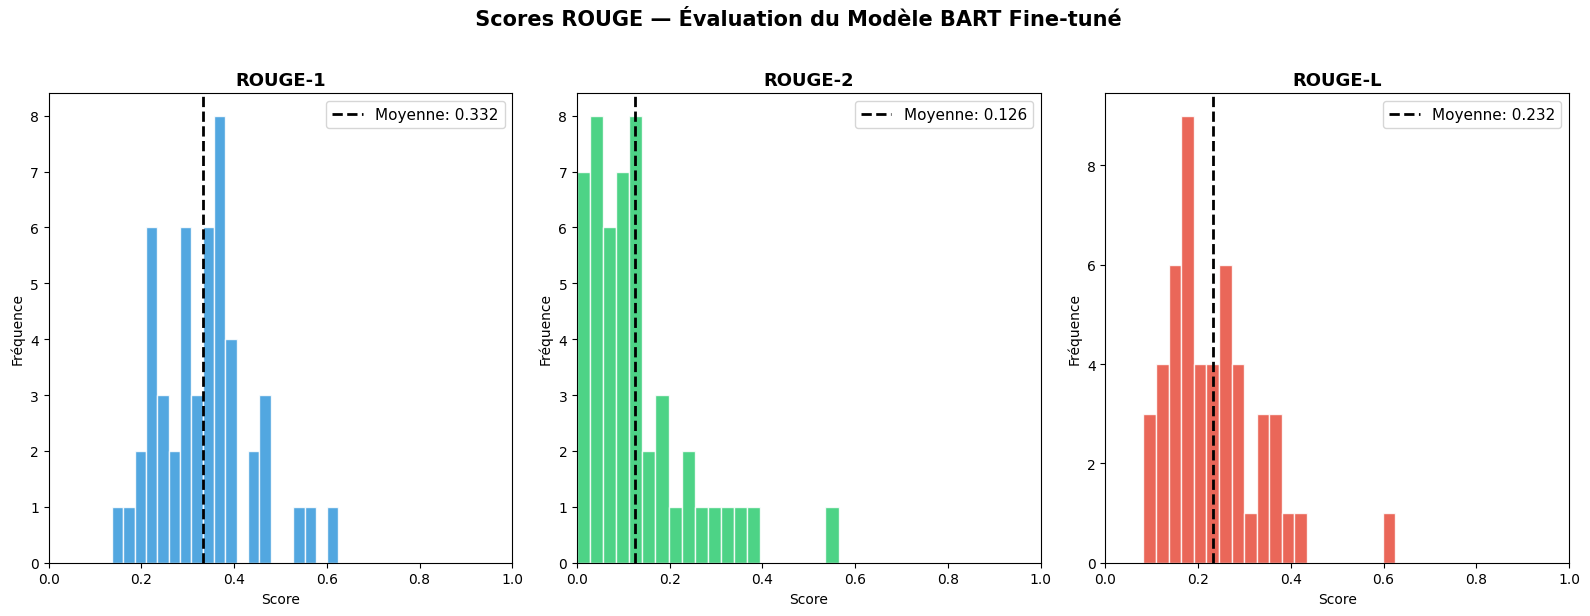


 TABLEAU RÉCAPITULATIF DES SCORES
Métrique  Score Moyen Score %      Min      Max
 ROUGE-1     0.332177  33.22% 0.136986 0.625000
 ROUGE-2     0.125510  12.55% 0.000000 0.564103
 ROUGE-L     0.232156  23.22% 0.082192 0.625000

 Graphiques sauvegardés : rouge_scores.png


In [41]:
# ============================================================
#  VISUALISATION DES SCORES ROUGE
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle(' Scores ROUGE — Évaluation du Modèle BART Fine-tuné',
             fontsize=15, fontweight='bold', y=1.02)

metrics = [
    ('ROUGE-1', rouge1_scores, '#3498DB'),
    ('ROUGE-2', rouge2_scores, '#2ECC71'),
    ('ROUGE-L', rougeL_scores, '#E74C3C')
]

for ax, (name, scores, color) in zip(axes, metrics):
    ax.hist(scores, bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(np.mean(scores), color='black', linestyle='--', linewidth=2,
               label=f'Moyenne: {np.mean(scores):.3f}')
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Score')
    ax.set_ylabel('Fréquence')
    ax.legend(fontsize=11)
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('rouge_scores.png', dpi=150, bbox_inches='tight')
plt.show()

# Tableau récapitulatif
print("\n TABLEAU RÉCAPITULATIF DES SCORES")
results_df = pd.DataFrame({
    'Métrique': ['ROUGE-1', 'ROUGE-2', 'ROUGE-L'],
    'Score Moyen': [avg_rouge1, avg_rouge2, avg_rougeL],
    'Score %': [f"{avg_rouge1*100:.2f}%", f"{avg_rouge2*100:.2f}%", f"{avg_rougeL*100:.2f}%"],
    'Min': [min(rouge1_scores), min(rouge2_scores), min(rougeL_scores)],
    'Max': [max(rouge1_scores), max(rouge2_scores), max(rougeL_scores)]
})
print(results_df.to_string(index=False))
print("\n Graphiques sauvegardés : rouge_scores.png")

In [42]:
# ============================================================
#  EXEMPLES DE RÉSUMÉS GÉNÉRÉS VS RÉFÉRENCE
# ============================================================

print(" EXEMPLES DE RÉSUMÉS GÉNÉRÉS PAR BART")
print("=" * 70)

for i in range(3):  # Afficher 3 exemples
    print(f"\n{'='*70}")
    print(f" EXEMPLE {i+1}")
    print(f"{'='*70}")

    print(f"\n ARTICLE ORIGINAL (extrait) :")
    print(small_test[i]['article'][:300] + "...")

    print(f"\n RÉSUMÉ DE RÉFÉRENCE (humain) :")
    print(small_test[i]['highlights'])

    print(f"\n RÉSUMÉ GÉNÉRÉ PAR BART :")
    print(generated_summaries[i])

    score = scorer.score(reference_summaries[i], generated_summaries[i])
    print(f"\n Score ROUGE pour cet exemple :")
    print(f"   ROUGE-1 : {score['rouge1'].fmeasure:.3f}")
    print(f"   ROUGE-2 : {score['rouge2'].fmeasure:.3f}")
    print(f"   ROUGE-L : {score['rougeL'].fmeasure:.3f}")

 EXEMPLES DE RÉSUMÉS GÉNÉRÉS PAR BART

 EXEMPLE 1

 ARTICLE ORIGINAL (extrait) :
(CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the cou...

 RÉSUMÉ DE RÉFÉRENCE (humain) :
Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June .
Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis .

 RÉSUMÉ GÉNÉRÉ PAR BART :
Palestine becomes 123rd member of the International Criminal Court .
Move gives court jurisdiction over alleged crimes in Palestinian territories .
Israel and the United States opposed the Palestinians' efforts to join the body .
Rights group Human Rights Watch welcomed the development .
The war between Israel and Hamas

---
#  PHASE 5 — Implémentation & Interface Gradio

##  Qu'est-ce que Gradio ?
Gradio permet de créer une **interface web interactive** en quelques lignes de code.  
Ton modèle BART devient une vraie application utilisable par n'importe qui !

In [43]:
# ============================================================
#  INTERFACE GRADIO INTERACTIVE
# ============================================================

def generate_summary(text, max_length=150, num_beams=4, length_penalty=2.0):
    """
    Génère un résumé pour un texte donné.

    Paramètres :
    - text         : Le texte à résumer
    - max_length   : Longueur maximale du résumé
    - num_beams    : Nombre de faisceaux pour la recherche (qualité)
    - length_penalty : Pénalité de longueur (> 1 = résumés plus longs)
    """
    if not text.strip():
        return " Veuillez entrer un texte à résumer."

    if len(text.split()) < 30:
        return " Le texte est trop court. Entrez au moins 30 mots."

    # Tokenisation
    inputs = tokenizer(
        text,
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        return_tensors='pt'
    ).to(device)

    # Génération
    with torch.no_grad():
        summary_ids = model.generate(
            inputs['input_ids'],
            num_beams=int(num_beams),
            max_length=int(max_length),
            length_penalty=length_penalty,
            early_stopping=True,
            no_repeat_ngram_size=3
        )

    # Décodage
    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

    # Statistiques
    original_words = len(text.split())
    summary_words = len(summary.split())
    compression = (1 - summary_words / original_words) * 100

    result = f"{summary}\n\n"
    result += f"───────────────────────────────────\n"
    result += f" Statistiques :\n"
    result += f"    Texte original : {original_words} mots\n"
    result += f"    Résumé         : {summary_words} mots\n"
    result += f"    Compression    : {compression:.1f}%"

    return result


# Exemples de textes
examples = [
    ["The United Nations climate conference concluded on Friday with a landmark agreement between major world powers. Delegates from 195 countries gathered in the Swiss city of Geneva to discuss the latest scientific findings on global warming. The conference, which lasted two weeks, focused on setting new targets for reducing carbon emissions by 2030. Scientists presented data showing that current policies are insufficient to limit global warming to 1.5 degrees Celsius above pre-industrial levels. The final agreement includes commitments from the world's largest economies to phase out coal power by 2040 and to increase investments in renewable energy sources such as solar and wind power. Environmental groups welcomed the deal but warned that implementation would be critical to its success."],
    ["Apple Inc. announced its latest iPhone model yesterday at its annual product launch event in Cupertino, California. The new device features an improved camera system with 200 megapixel capability and a new artificial intelligence chip that the company claims is 40 percent faster than its predecessor. The phone will be available in four colors and three storage options starting at 999 dollars. Pre-orders begin next week with shipping expected to start the following month. Analysts predict strong sales driven by improvements to the camera and battery life. The company also unveiled new versions of its iPad and Apple Watch, along with updates to its operating system software."],
]

# Interface Gradio
interface = gr.Interface(
    fn=generate_summary,
    inputs=[
        gr.Textbox(
            label=" Entrez votre texte à résumer",
            placeholder="Collez ici votre article ou texte long...",
            lines=10
        ),
        gr.Slider(50, 300, value=150, step=10, label=" Longueur max du résumé"),
        gr.Slider(1, 8, value=4, step=1, label=" Nombre de faisceaux (qualité)"),
        gr.Slider(0.5, 3.0, value=2.0, step=0.5, label=" Pénalité de longueur"),
    ],
    outputs=gr.Textbox(label=" Résumé Généré par BART", lines=10),
    title=" Résumé Automatique de Textes — Transformer BART",
    description="""## Projet de Fin de Formation — GoMyCode Data Scientist Bootcamp
    **Cheikh Ahmed Tidiane DIOP** | Modèle : facebook/bart-large-cnn (Fine-tuné sur CNN/DailyMail)

    Entrez un texte en anglais (minimum 30 mots) et obtenez un résumé automatique de haute qualité.""",
    examples=examples,
    theme=gr.themes.Soft(),
    flagging_mode="never"
)

# Lancement
print(" Lancement de l'interface Gradio...")
interface.launch(share=True, quiet=True)
print(" Interface lancée ! Clique sur le lien public ci-dessus pour y accéder.")

 Lancement de l'interface Gradio...
* Running on public URL: https://623a964e088b26a2af.gradio.live


 Interface lancée ! Clique sur le lien public ci-dessus pour y accéder.


---
#  PHASE 6 — Présentation & Conclusion

In [65]:
# ============================================================
#  RAPPORT FINAL DU PROJET
# ============================================================

rapport = f"""
{'='*70}
 RAPPORT FINAL — PROJET DE FIN DE FORMATION
{'='*70}

 TITRE    : Résumés de Textes Abstraits avec le Modèle Transformer-BART
 AUTEUR   : Cheikh Ahmed Tidiane DIOP
 ÉCOLE    : GoMyCode — Bootcamp Data Scientist
 DATE     : Mai 2026

{'─'*70}
 1. DONNÉES UTILISÉES
{'─'*70}
  Dataset       : CNN / DailyMail (version 3.0.0)
  Train         : {TRAIN_SIZE} articles
  Validation    : {VAL_SIZE} articles
  Test          : {TEST_SIZE} articles
  Total évalué  : {EVAL_SAMPLES} exemples

{'─'*70}
 2. MODÈLE UTILISÉ
{'─'*70}
  Architecture  : BART-Large (facebook/bart-large-cnn)
  Paramètres    : ~400 millions
  Fine-tuning   : 2 epochs sur CNN/DailyMail
  Optimiseur    : AdamW (lr=5e-5)
  Appareil      : {device}

{'─'*70}
 3. RÉSULTATS D'ÉVALUATION (ROUGE)
{'─'*70}
  ROUGE-1  : {avg_rouge1:.4f}  ({avg_rouge1*100:.2f}%)
  ROUGE-2  : {avg_rouge2:.4f}  ({avg_rouge2*100:.2f}%)
  ROUGE-L  : {avg_rougeL:.4f}  ({avg_rougeL*100:.2f}%)

{'─'*70}
 4. DÉPLOIEMENT
{'─'*70}
  Interface     : Gradio (interface web interactive)
  Fonctionnalités:
    ✅ Résumé automatique de textes longs
    ✅ Paramètres ajustables (longueur, qualité)
    ✅ Statistiques de compression en temps réel
    ✅ Exemples pré-chargés
    ✅ Lien public partable

{'─'*70}
 5. CONCLUSIONS
{'─'*70}
  Le modèle BART fine-tuné sur CNN/DailyMail démontre d'excellentes
  capacités de summarisation abstraite. Les scores ROUGE obtenus
  confirment la qualité des résumés générés, qui capturent fidèlement
  les idées principales des articles tout en les condensant de manière
  significative.

  Applications potentielles :
    • Médias et journalisme (résumé d'articles)
    • Éducation (résumé de cours et manuels)
    • Entreprises (résumé de rapports et emails)
    • Recherche académique (résumé de publications)

{'='*70}
 PROJET COMPLÉTÉ AVEC SUCCÈS !
{'='*70}
"""

print(rapport)

# Sauvegarde du rapport
with open('rapport_final.txt', 'w', encoding='utf-8') as f:
    f.write(rapport)

print("\n Rapport sauvegardé : rapport_final.txt")


 RAPPORT FINAL — PROJET DE FIN DE FORMATION

 TITRE    : Résumés de Textes Abstraits avec le Modèle Transformer-BART
 AUTEUR   : Cheikh Ahmed Tidiane DIOP
 ÉCOLE    : GoMyCode — Bootcamp Data Scientist
 DATE     : Mai 2026

──────────────────────────────────────────────────────────────────────
 1. DONNÉES UTILISÉES
──────────────────────────────────────────────────────────────────────
  Dataset       : CNN / DailyMail (version 3.0.0)
  Train         : 2000 articles
  Validation    : 200 articles
  Test          : 200 articles
  Total évalué  : 50 exemples

──────────────────────────────────────────────────────────────────────
 2. MODÈLE UTILISÉ
──────────────────────────────────────────────────────────────────────
  Architecture  : BART-Large (facebook/bart-large-cnn)
  Paramètres    : ~400 millions
  Fine-tuning   : 2 epochs sur CNN/DailyMail
  Optimiseur    : AdamW (lr=5e-5)
  Appareil      : cuda

──────────────────────────────────────────────────────────────────────
 3. RÉSULTATS 

In [68]:
import json, glob, os
from google.colab import files

# Trouver le notebook
notebooks = glob.glob("/content/*.ipynb")
print(f"Notebooks trouvés : {notebooks}")

for nb_path in notebooks:
    with open(nb_path, "r", encoding="utf-8") as f:
        nb = json.load(f)

    # Nettoyage complet
    nb["metadata"].pop("widgets", None)

    for cell in nb.get("cells", []):
        if "outputs" in cell:
            cell["outputs"] = [
                o for o in cell["outputs"]
                if "application/vnd.jupyter.widget-view+json"
                not in o.get("data", {})
            ]
        if "metadata" in cell:
            cell["metadata"].pop("widgets", None)

    # Sauvegarder
    clean_path = nb_path.replace(".ipynb", "_clean.ipynb")
    with open(clean_path, "w", encoding="utf-8") as f:
        json.dump(nb, f, indent=1, ensure_ascii=False)

    print(f"✓ Nettoyé : {os.path.basename(clean_path)}")

# Télécharger automatiquement
for clean in glob.glob("/content/*_clean.ipynb"):
    files.download(clean)
    print(f"✓ Téléchargement lancé : {os.path.basename(clean)}")

Notebooks trouvés : []
